Batarya Ömür Tahmini Projesi (Battery Aging Prediction Project)

Veri analizi için model oluşturma ve testler yapma (Building the model for data analysis and testing).

1. Gerekli kütüphaneleri koda ekledim (Added essential libraries to the code).

In [69]:
#Got the essential libraries
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import optuna
from sklearn.model_selection import cross_val_score

/home/yasin6n/Masaüstü/Battery/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2. Analize hazır veriyi h5 dosyasından alıp, bu veriler ile bir Elastic Net lineer regresyon modeli eğittim,hiperparametre optimizasyonu yaptım ve test ettim
(Got the data ready for analysis from the h5 file, trained an Elastic Net lineer regression model with this data, did hyperparameter optimization and tested it).

In [28]:
#Defined features,target and battery groups matrices
Features_list = []
Target_list = []
Groups_list = []

#Defined error rates matrices for model statistics
fold_rmse_scores = []
fold_mae_scores = []

fold_rmse_opt_scores = []
fold_mae_opt_scores = []

#Opened the h5 file with features and target data, printed the feature names
with h5py.File("FastCharge__Features_Target.h5", "r") as h5f:
    first_battery = list(h5f.keys())[0]
    feature_names = h5f[first_battery]['Features'].attrs['Names']
    print("Features Used in the Model:")
    print(feature_names)
    
    #Got the features and target data, and grouped them under same battery name
    batteries = list(h5f.keys())
    for battery_index,battery_name in enumerate(batteries):
        features = h5f[battery_name]['Features'][:]
        target = h5f[battery_name]['Target'][:]
        
        Features_list.append(features)
        Target_list.append(target)

        num_cycles = features.shape[0]
        Groups_list.append(np.full(num_cycles, battery_index))

    #Combined all feature,target,groups values in one for each
    Features = np.vstack(Features_list)
    Target = np.concatenate(Target_list)
    Groups = np.concatenate(Groups_list)

    #Defined K-Fold Group for 5 different train-test configurations
    gkf = GroupKFold(n_splits=5)

    #Built the model and trained it
    model = ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=2000)
    
    #Built another model with optimized hyperparameters and trained it for future comparison
    model_opt = ElasticNet(alpha=1e-9, l1_ratio=0.1, random_state=42, max_iter=2000)

    #Splitted the batteries with indexes gotten from K-Fold Group
    for fold, (train_index, test_index) in enumerate(gkf.split(Features, Target, Groups)):
        print(f"--- FOLD {fold+1} ---")

        #Defined the Features and Target for train and test datasets
        X_train, X_test = Features[train_index], Features[test_index]
        y_train, y_test = Target[train_index], Target[test_index]

        #Replaced NaN values with the median of the column with SimpleImputer
        imputer = SimpleImputer(strategy='median')
        X_train_clean = imputer.fit_transform(X_train)
        X_test_clean = imputer.transform(X_test)

        #Normalized the Features with only train dataset values with MinMaxScaler
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train_clean)
        X_test_scaled = scaler.transform(X_test_clean)

        #Fitted the model for one configuration
        print("Elastic Net is training...")
        model.fit(X_train_scaled, y_train)
        model_opt.fit(X_train_scaled, y_train)
        
        #Inspected the feature coefficients
        print("Feature Coefficients           :", np.round(model.coef_, 4))
        print("Feature Coefficients(Optimized):", np.round(model_opt.coef_, 4))
        
        #Did the prediction and calculated the error rates
        y_prediction = model.predict(X_test_scaled)
        rmse = np.sqrt(mean_squared_error(y_test, y_prediction))
        mae = mean_absolute_error(y_test, y_prediction)

        y_prediction_opt = model_opt.predict(X_test_scaled)
        rmse_opt = np.sqrt(mean_squared_error(y_test, y_prediction_opt))
        mae_opt = mean_absolute_error(y_test, y_prediction_opt)
        
        #Added error rates to the matrices
        fold_rmse_scores.append(rmse)
        fold_mae_scores.append(mae)

        fold_rmse_opt_scores.append(rmse_opt)
        fold_mae_opt_scores.append(mae_opt)
        
        print(f"RMSE           : {rmse:.4f} | MAE           : {mae:.4f}")
        print(f"RMSE(Optimized): {rmse_opt:.4f} | MAE(Optimized): {mae_opt:.4f}")

    #Printed the results
    print("\n" + "="*40)
    print("ELASTIC NET 5-FOLD ERROR RATE RESULTS:")
    print(f"Mean RMSE           : {np.mean(fold_rmse_scores):.4f}")
    print(f"Mean MAE            : {np.mean(fold_mae_scores):.4f}")
    print(f"Mean RMSE(Optimized): {np.mean(fold_rmse_opt_scores):.4f}")
    print(f"Mean MAE(Optimized) : {np.mean(fold_mae_opt_scores):.4f}")

Features Used in the Model:
['Internal_Resistance' 'Temperature_Variance' 'dQ/dV_Kurtosis'
 'dQ/dV_Skewness' 'dQ/dV_Peakheight' 'dQ/dV_Variance_log']
--- FOLD 1 ---
Elastic Net is training...
Feature Coefficients           : [-0.     -0.     -0.      0.      0.      0.4622]
Feature Coefficients(Optimized): [ 0.0188  0.0052  0.3403  0.5463 -0.6265  0.823 ]
RMSE           : 0.0226 | MAE           : 0.0178
RMSE(Optimized): 0.0168 | MAE(Optimized): 0.0100
--- FOLD 2 ---
Elastic Net is training...
Feature Coefficients           : [-0.     -0.     -0.      0.      0.      0.4553]
Feature Coefficients(Optimized): [ 0.0214  0.0038  0.3593  0.5669 -0.6353  0.8206]
RMSE           : 0.0211 | MAE           : 0.0171
RMSE(Optimized): 0.0114 | MAE(Optimized): 0.0085
--- FOLD 3 ---
Elastic Net is training...
Feature Coefficients           : [-0.     -0.     -0.      0.0527  0.      0.3727]
Feature Coefficients(Optimized): [ 0.0244 -0.0034  0.1608  0.3703 -0.3953  0.5727]
RMSE           : 0.0245 | MAE 

3. Modelin optimizasyon sonrası son train-test konfigürasyonunun sonuçlarını kullanarak grafikler çizdirdim
(Plotted graphs with the results from last train-test configuration of the model after optimization).

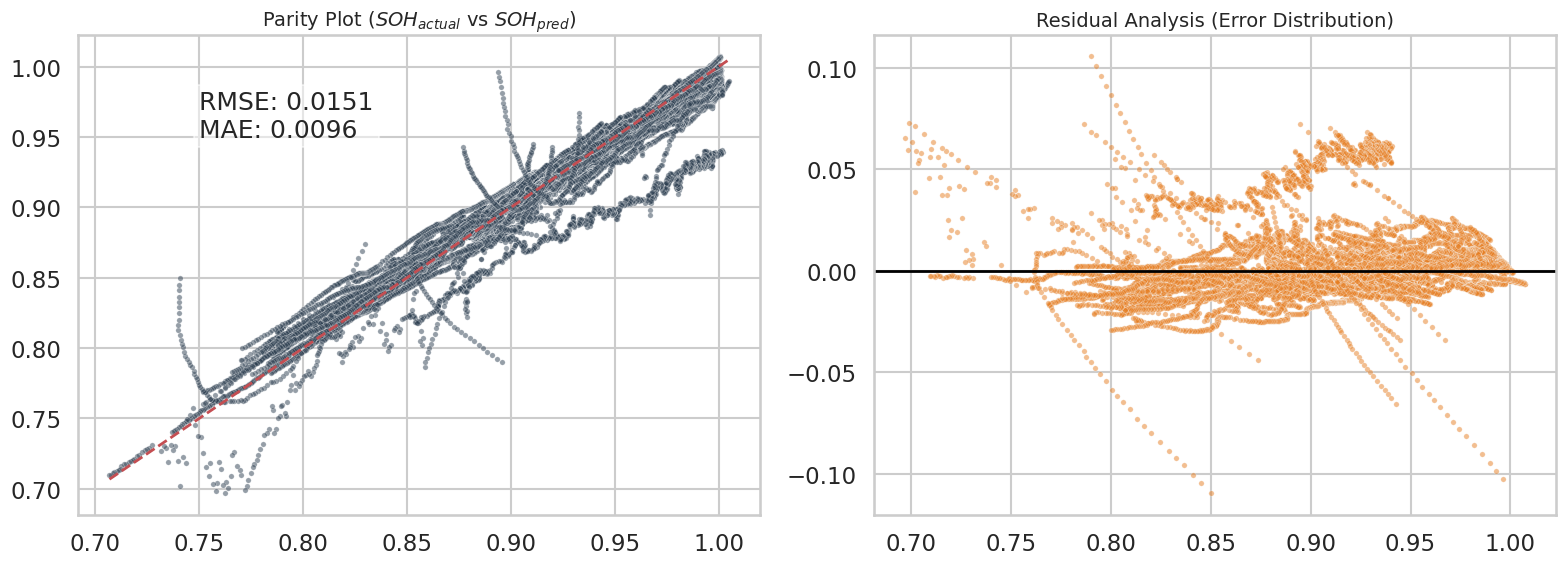

In [17]:
#Set the seaborn theme
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Plotted the parity(Real vs Predicted)
sns.scatterplot(x=y_test, y=y_prediction_opt, alpha=0.5, color="#2c3e50", s=15, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(r'Parity Plot ($SOH_{actual}$ vs $SOH_{pred}$)', fontsize=14)


#Plotted the residuals ()
residuals = y_test - y_prediction_opt
sns.scatterplot(x=y_prediction_opt, y=residuals, alpha=0.5, color="#e67e22", s=15, ax=axes[1])
axes[1].axhline(0, color='black', linestyle='-', lw=2)
axes[1].set_title('Residual Analysis (Error Distribution)', fontsize=14)
axes[0].text(0.75, 0.95, f'RMSE: {rmse_opt:.4f}\nMAE: {mae_opt:.4f}', bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

4. Hiperparametre optimizasyonu öncesi ve sonrası Elastic Net modelinin katsayılarını karşılaştırdım
(Compared the coefficients of the Elastic Net model for before-after hyperparameter optimization)

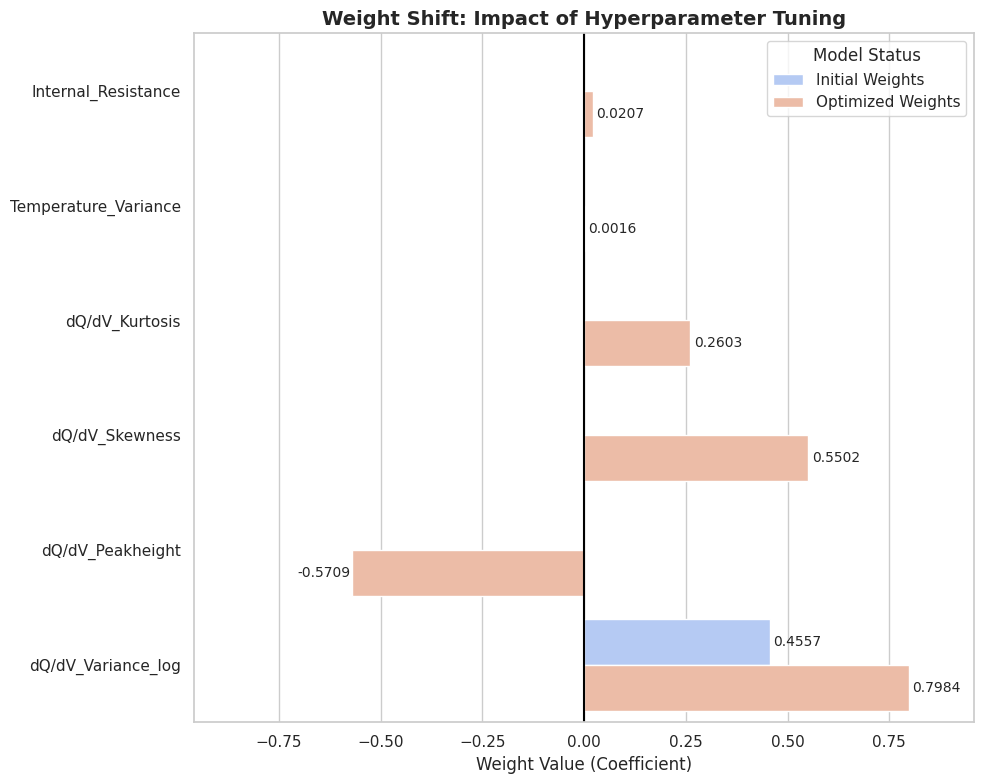

In [27]:
#Defined the coefficient data for features
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Initial Weights': model.coef_,
    'Optimized Weights': model_opt.coef_
}).melt(id_vars='Feature', var_name='Model Status', value_name='Weight Value')

#Defined the size of the plot
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

#Plotted a bar graph
ax = sns.barplot(
    data=coef_df, 
    y='Feature',      
    x='Weight Value', 
    hue='Model Status', 
    palette='coolwarm'
)

#Adjusted the graph for small values
max_val = coef_df['Weight Value'].abs().max()
plt.xlim(-max_val * 1.2, max_val * 1.2) 

#Setting up the title and labels
plt.title('Weight Shift: Impact of Hyperparameter Tuning', fontweight='bold', fontsize=14)
plt.xlabel('Weight Value (Coefficient)', fontsize=12)
plt.ylabel('') 
plt.axvline(0, color='black', lw=1.5) 

#Writing the coefficient values on the graph
for p in ax.patches:
    width = p.get_width()
    if abs(width) > 0:
        ax.annotate(f'{width:.4f}', 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha = 'center', va = 'center', 
                    xytext = (20 if width > 0 else -20, 0), 
                    textcoords = 'offset points',
                    fontsize=10)

plt.tight_layout()
plt.show()

5. Modelin batalyalar özelinde hata oranlarını hesapladım, en yüksek ve en düşük hata oranına sahip piller için model performansını grafiklerle karşılaştırdım
(Calculated the error rates for individual batteries, compared the model performance with graphics on batteries with highest and lowest error rates).

Rank  | Best Batteries (Low Error)         | Worst Batteries (High Error)  
---------------------------------------------------------------------------
#1    | FastCharge_000006_CH35_st (0.0021) | FastCharge_000026_CH5_str (0.1177)
#2    | FastCharge_000012_CH13_st (0.0026) | FastCharge_000026_CH6_str (0.0840)
#3    | FastCharge_000001_CH38_st (0.0029) | FastCharge_000004_CH2_str (0.0517)
#4    | FastCharge_000001_CH16_st (0.0030) | FastCharge_000036_CH48_st (0.0489)
#5    | FastCharge_000012_CH37_st (0.0031) | FastCharge_000004_CH1_str (0.0484)
#6    | FastCharge_000002_CH42_st (0.0035) | FastCharge_000004_CH3_str (0.0438)
#7    | FastCharge_000012_CH21_st (0.0035) | FastCharge_000052_CH41_st (0.0300)
#8    | FastCharge_000006_CH19_st (0.0037) | FastCharge_000017_CH46_st (0.0290)
#9    | FastCharge_000015_CH20_st (0.0038) | FastCharge_000049_CH37_st (0.0288)
#10   | FastCharge_000042_CH36_st (0.0038) | FastCharge_000023_CH37_st (0.0288)


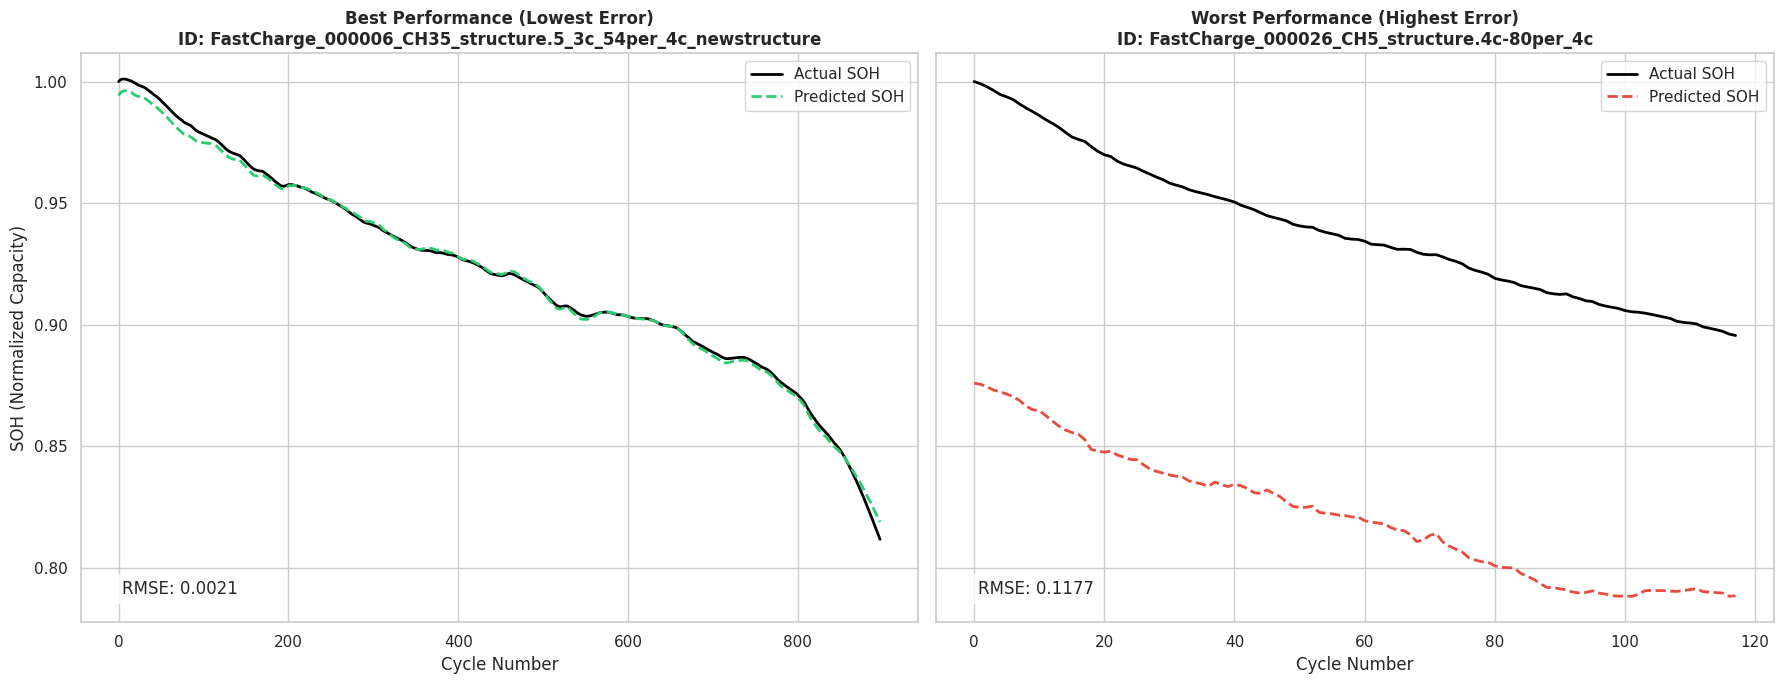

In [34]:
#Defined features,target and battery groups matrices
Features_list = []
Target_list = []
Groups_list = []

#Defined a dictionary to save individual battery errors and results
battery_errors = {}
battery_results = {}

#Opened the h5 file with features and target data 
with h5py.File("FastCharge__Features_Target.h5", "r") as h5f:
    batteries = list(h5f.keys())

    #Got the features and target data, and grouped them under same battery name
    for battery_index,battery_name in enumerate(batteries):
        features = h5f[battery_name]['Features'][:]
        target = h5f[battery_name]['Target'][:]
        
        Features_list.append(features)
        Target_list.append(target)

        num_cycles = features.shape[0]
        Groups_list.append(np.full(num_cycles, battery_index))

    #Combined all feature,target,groups values in one for each
    Features = np.vstack(Features_list)
    Target = np.concatenate(Target_list)
    Groups = np.concatenate(Groups_list)

    #Defined K-Fold Group for 5 different train-test configurations
    gkf = GroupKFold(n_splits=5)

    #Built up the model and trained it
    model = ElasticNet(alpha=1e-9, l1_ratio=0.1, random_state=42, max_iter=2000)

    #Splitted the batteries with indexes gotten from K-Fold Group
    for fold, (train_index, test_index) in enumerate(gkf.split(Features, Target, Groups)):

        #Defined the Features and Target for train and test datasets
        X_train, X_test = Features[train_index], Features[test_index]
        y_train, y_test = Target[train_index], Target[test_index]

        #Replaced NaN values with the median of the column with SimpleImputer
        imputer = SimpleImputer(strategy='median')
        X_train_clean = imputer.fit_transform(X_train)
        X_test_clean = imputer.transform(X_test)

        #Normalized the Features with only Training Data values with MinMaxScaler
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train_clean)
        X_test_scaled = scaler.transform(X_test_clean)

        #Fitted the model for one configuration
        model.fit(X_train_scaled, y_train)

        #Did the prediction and measured error rates
        y_prediction = model.predict(X_test_scaled)
        
        #Found the unique batteries to inspect their error rates 
        test_groups = Groups[test_index]
        unique_batteries = np.unique(test_groups)
        for bat_idx in unique_batteries:
            mask = (test_groups == bat_idx)
            bat_y_true = y_test[mask]
            bat_y_pred = y_prediction[mask]
            bat_rmse = np.sqrt(mean_squared_error(bat_y_true, bat_y_pred))
            bat_name = batteries[bat_idx]
            
            #Saved the values and error rates for plotting
            battery_errors[bat_name] = bat_rmse
            battery_results[bat_name] = {
                'true': bat_y_true,
                'pred': bat_y_pred,
                'rmse': bat_rmse
            }

#Sorted the error rates and got the top 10 and bottom 10 error rates
sorted_errors = sorted(battery_errors.items(), key=lambda item: item[1])
best_10 = sorted_errors[:10]       # En düşük hatalı ilk 10
worst_10 = sorted_errors[-10:][::-1] # En yüksek hatalı son 10 (ters çevrilmiş)

#Printed the results
print(f"{'Rank':<5} | {'Best Batteries (Low Error)':<30}     | {'Worst Batteries (High Error)':<30}")
print("-" * 75)
for i in range(10):
    b_name, b_err = best_10[i]
    w_name, w_err = worst_10[i]
    print(f"#{i+1:<4} | {b_name[:25]:<25} ({b_err:.4f}) | {w_name[:25]:<25} ({w_err:.4f})")

#Found the worst and best resulted batteries
best_bat_name = best_10[0][0]
worst_bat_name = worst_10[0][0]

#Started poltting the results for both of them for comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
sns.set_style("whitegrid")

#Set up the graph,title,axis
for i, (b_name, title, color) in enumerate([
    (best_bat_name, "Best Performance (Lowest Error)", "#2ecc71"),
    (worst_bat_name, "Worst Performance (Highest Error)", "#e74c3c")
]):
    data = battery_results[b_name]
    cycles = range(len(data['true']))
    
    axes[i].plot(cycles, data['true'], label='Actual SOH', color='black', lw=2)
    axes[i].plot(cycles, data['pred'], label='Predicted SOH', color=color, linestyle='--', lw=2)
    
    axes[i].set_title(f"{title}\nID: {b_name}", fontweight='bold')
    axes[i].set_xlabel('Cycle Number')
    axes[i].legend()
    axes[i].text(0.05, 0.05, f"RMSE: {data['rmse']:.4f}", transform=axes[i].transAxes, 
                 bbox=dict(facecolor='white', alpha=0.8))

axes[0].set_ylabel('SOH (Normalized Capacity)')
plt.tight_layout()
plt.show()

6. Aynı veri ile bir Random Forest regresyon modeli eğittim, bu modele de hiperparametre optimizsayonu yaptım ve test ettim
(Trained a Random Forest regressor with same data, did hyperparameter optimization for this model as well and tested it).

In [73]:
#Defined features,target and battery groups matrices
Features_list = []
Target_list = []
Groups_list = []

#Defined error rates for model statistics
fold_rmse_scores = []
fold_mae_scores = []

#Opened the h5 file with features and target data 
with h5py.File("FastCharge__Features_Target.h5", "r") as h5f:
    batteries = list(h5f.keys())

    #Got the features and target data, and grouped them under same battery name
    for battery_index,battery_name in enumerate(batteries):
        features = h5f[battery_name]['Features'][:]
        target = h5f[battery_name]['Target'][:]
        
        Features_list.append(features)
        Target_list.append(target)

        num_cycles = features.shape[0]
        Groups_list.append(np.full(num_cycles, battery_index))

    #Combining all feature,target,groups values in one for each
    Features = np.vstack(Features_list)
    Target = np.concatenate(Target_list)
    Groups = np.concatenate(Groups_list)

    #Defined K-Fold Group for 5 different train-test configurations
    gkf = GroupKFold(n_splits=5)

    #Built up the model and trained it
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    
    #Built another model with optimized hyperparameters and trained it for future comparison
    model_opt = RandomForestRegressor(n_estimators=100, min_samples_split=10, min_samples_leaf=5, max_features='log2', max_depth=25, random_state=42, n_jobs=-1)

    #Splitted the batteries with indexes gotten from K-Fold Group
    for fold, (train_idx, test_idx) in enumerate(gkf.split(Features, Target, Groups)):
        print(f"--- FOLD {fold+1} ---")

        X_train, X_test = Features[train_idx], Features[test_idx]
        y_train, y_test = Target[train_idx], Target[test_idx]

        #Normalized the Features with only Training Data values by using MinMaxScaler
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    
        print("Training the model (This process might take couple minutes)...")
        model.fit(X_train_scaled, y_train)
        model_opt.fit(X_train_scaled, y_train)
        
        #Inspected the feature importances
        print("Feature Importances:", np.round(model.feature_importances_, 4))
        print("Feature Importances:", np.round(model_opt.feature_importances_, 4))

        #Did the prediction and calculated the error rates
        y_prediction = model.predict(X_test_scaled)
        rmse = np.sqrt(mean_squared_error(y_test, y_prediction))
        mae = mean_absolute_error(y_test, y_prediction)

        y_prediction_opt = model_opt.predict(X_test_scaled)
        rmse_opt = np.sqrt(mean_squared_error(y_test, y_prediction_opt))
        mae_opt = mean_absolute_error(y_test, y_prediction_opt)
        
        #Added error rates to the matrices
        fold_rmse_scores.append(rmse)
        fold_mae_scores.append(mae)

        fold_rmse_opt_scores.append(rmse_opt)
        fold_mae_opt_scores.append(mae_opt)
        
        print(f"RMSE           : {rmse:.4f} | MAE           : {mae:.4f}")
        print(f"RMSE(Optimized): {rmse_opt:.4f} | MAE(Optimized): {mae_opt:.4f}")
        
    #Printed the results
    print("\n" + "="*50)
    print("RANDOM FOREST REGRESSOR 5-FOLD ERROR RATE RESULTS:")
    print(f"Mean RMSE           : {np.mean(fold_rmse_scores):.4f}")
    print(f"Mean MAE            : {np.mean(fold_mae_scores):.4f}")
    print(f"Mean RMSE(Optimized): {np.mean(fold_rmse_opt_scores):.4f}")
    print(f"Mean MAE(Optimized) : {np.mean(fold_mae_opt_scores):.4f}")

--- FOLD 1 ---
Training the model (This process might take couple minutes)...
Feature Importances: [0.0222 0.0144 0.0131 0.0781 0.0194 0.8528]
Feature Importances: [0.0778 0.019  0.0406 0.058  0.3301 0.4744]
RMSE           : 0.0165 | MAE           : 0.0092
RMSE(Optimized): 0.0156 | MAE(Optimized): 0.0090
--- FOLD 2 ---
Training the model (This process might take couple minutes)...
Feature Importances: [0.0279 0.017  0.0155 0.0749 0.0231 0.8416]
Feature Importances: [0.0793 0.0201 0.0434 0.0592 0.3507 0.4474]
RMSE           : 0.0128 | MAE           : 0.0088
RMSE(Optimized): 0.0117 | MAE(Optimized): 0.0085
--- FOLD 3 ---
Training the model (This process might take couple minutes)...
Feature Importances: [0.0182 0.0122 0.0112 0.0782 0.021  0.8592]
Feature Importances: [0.0827 0.0171 0.0394 0.0594 0.3363 0.465 ]
RMSE           : 0.0179 | MAE           : 0.0105
RMSE(Optimized): 0.0174 | MAE(Optimized): 0.0104
--- FOLD 4 ---
Training the model (This process might take couple minutes)...
Feat

7. Bu modelin de optimizasyon sonrası son train-test konfigürasyonunun sonuçlarını kullanarak grafikler çizdirdim
(Plotted graphs with the results from last train-test configuration of this model as well after optimization).

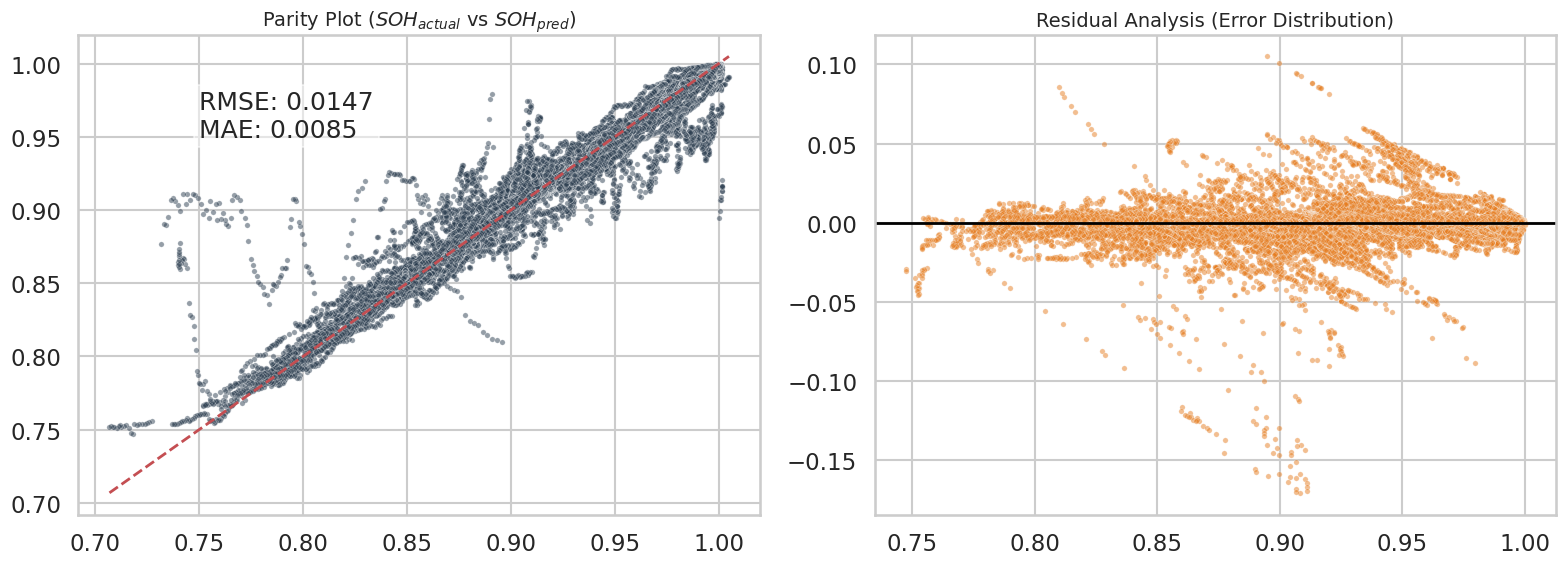

In [74]:
#Set the seaborn theme
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Plotted the parity(Real vs Predicted)
sns.scatterplot(x=y_test, y=y_prediction_opt, alpha=0.5, color="#2c3e50", s=15, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(r'Parity Plot ($SOH_{actual}$ vs $SOH_{pred}$)', fontsize=14)


#Plotted the residuals ()
residuals = y_test - y_prediction_opt
sns.scatterplot(x=y_prediction_opt, y=residuals, alpha=0.5, color="#e67e22", s=15, ax=axes[1])
axes[1].axhline(0, color='black', linestyle='-', lw=2)
axes[1].set_title('Residual Analysis (Error Distribution)', fontsize=14)
axes[0].text(0.75, 0.95, f'RMSE: {rmse_opt:.4f}\nMAE: {mae_opt:.4f}', bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

8. Hiperparametre optimizasyonu öncesi ve sonrası Random Forest modelinin öznitelik önemlerini karşılaştırdım
(Compared the feature importances of the Random Forest model for before-after hyperparameter optimization).

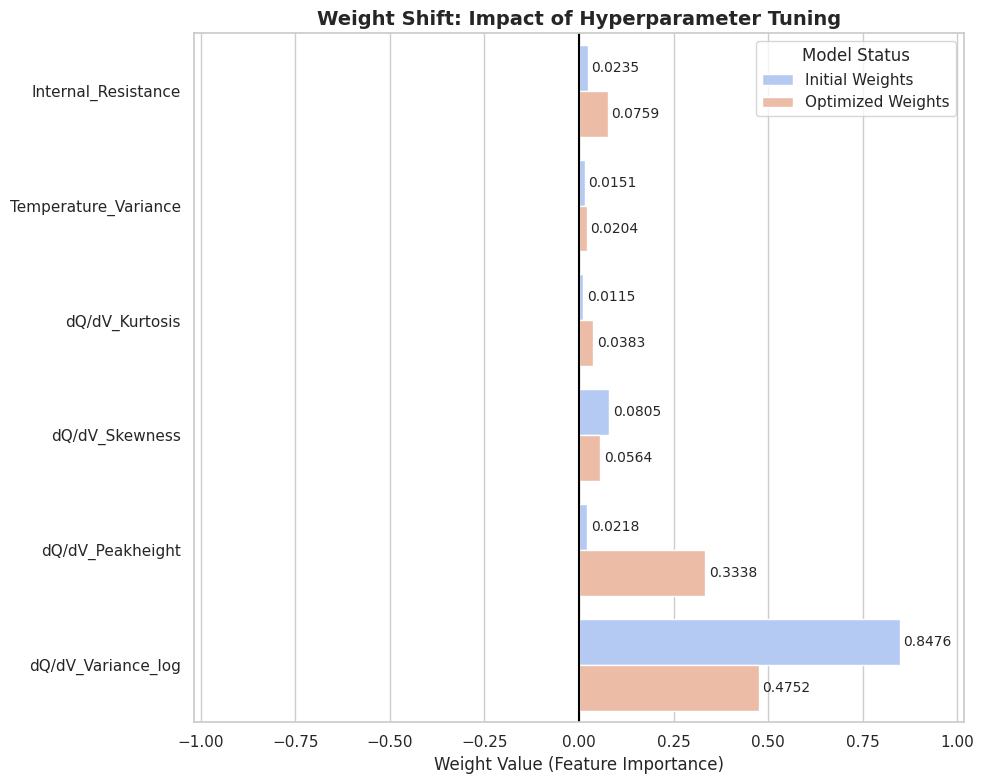

In [75]:
#Defined the feature importance data for features
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Initial Weights': model.feature_importances_,
    'Optimized Weights': model_opt.feature_importances_
}).melt(id_vars='Feature', var_name='Model Status', value_name='Weight Value')

#Defined the size of the plot
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

#Plotted a bar graph
ax = sns.barplot(
    data=coef_df, 
    y='Feature',      
    x='Weight Value', 
    hue='Model Status', 
    palette='coolwarm'
)

#Adjusted the graph for small values
max_val = coef_df['Weight Value'].abs().max()
plt.xlim(-max_val * 1.2, max_val * 1.2) 

#Setting up the title and labels
plt.title('Weight Shift: Impact of Hyperparameter Tuning', fontweight='bold', fontsize=14)
plt.xlabel('Weight Value (Feature Importance)', fontsize=12)
plt.ylabel('') 
plt.axvline(0, color='black', lw=1.5) 

#Writing the feature importance values on the graph
for p in ax.patches:
    width = p.get_width()
    if abs(width) > 0:
        ax.annotate(f'{width:.4f}', 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha = 'center', va = 'center', 
                    xytext = (20 if width > 0 else -20, 0), 
                    textcoords = 'offset points',
                    fontsize=10)

plt.tight_layout()
plt.show()